In [28]:
# Importing necessary libraries
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Finding the path of my Directory

In [31]:
os.getcwd()

'/Users/adarshkandoth/DS-680 project'

In [33]:
file_path = '/Users/adarshkandoth/DS-680_project/Zomato.csv'

## Displaying the 1st Five rows of the Data that has been uploaded

In [36]:
df = pd.read_csv('/Users/adarshkandoth/DS-680 project/Zomato.csv')
print("First 5 rows of the Zomato Dataset:\n")
print(df.head())

First 5 rows of the Zomato Dataset:

       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0xcdcd      DEHRES17DEL01                 36.0                      4.2   
1  0xd987      KOCRES16DEL01                 21.0                      4.7   
2  0x2784     PUNERES13DEL03                 23.0                      4.7   
3  0xc8b6     LUDHRES15DEL02                 34.0                      4.3   
4  0xdb64      KNPRES14DEL02                 24.0                      4.7   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            30.327968             78.046106                   30.397968   
1            10.003064             76.307589                   10.043064   
2            18.562450             73.916619                   18.652450   
3            30.899584             75.809346                   30.919584   
4            26.463504             80.372929                   26.593504   

   Delivery_location_longitude  Order

## Considering only those fields which are Numberic for getting the Correlation Analysis and Heatmap

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Ve

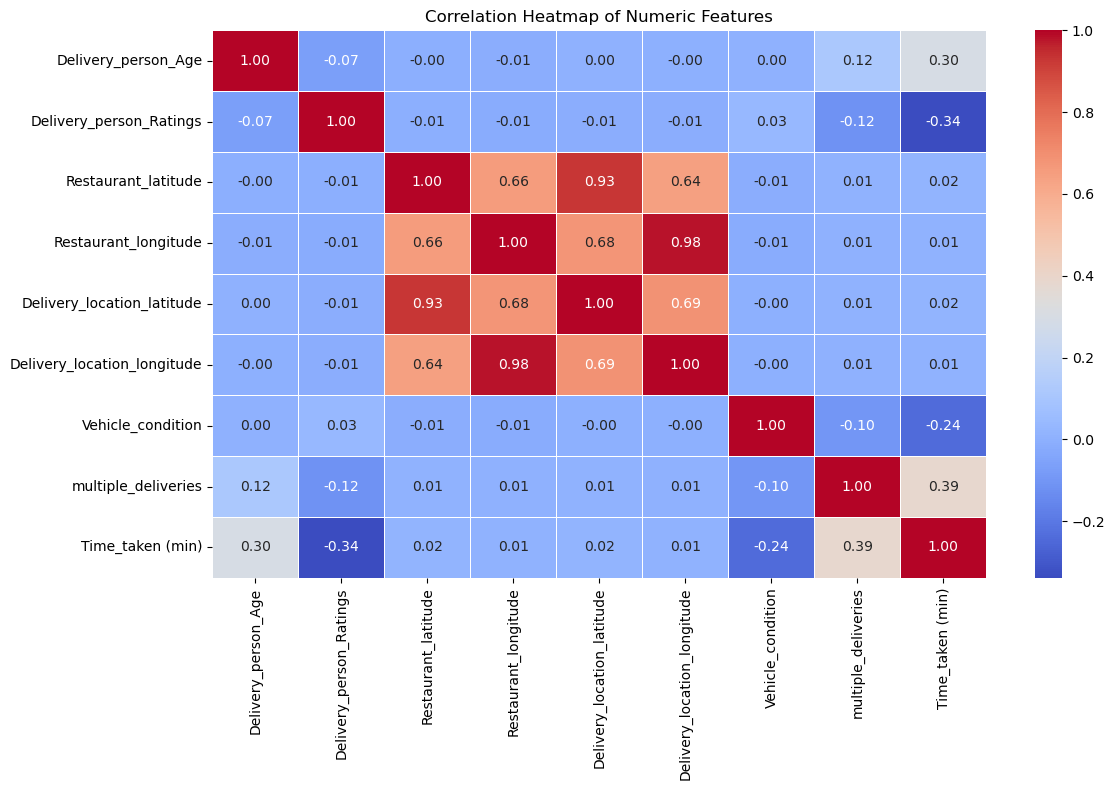

In [39]:
print("Dataset Info:")
print(df.info())

# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Drop rows with missing values for clean correlation analysis
numeric_df_cleaned = numeric_df.dropna()

# Compute the correlation matrix
correlation_matrix = numeric_df_cleaned.corr()

# Display the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## Checking for the missing Values

In [42]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values
print("Missing values in each column:")
print(missing_values[missing_values > 0])

# Optionally, check percentage of missing values
print("\nPercentage of missing values:")
print((df.isnull().mean() * 100).round(2))


Missing values in each column:
Delivery_person_Age        1854
Delivery_person_Ratings    1908
Time_Orderd                1731
Weather_conditions          616
Road_traffic_density        601
multiple_deliveries         993
Festival                    228
City                       1200
dtype: int64

Percentage of missing values:
ID                             0.00
Delivery_person_ID             0.00
Delivery_person_Age            4.07
Delivery_person_Ratings        4.19
Restaurant_latitude            0.00
Restaurant_longitude           0.00
Delivery_location_latitude     0.00
Delivery_location_longitude    0.00
Order_Date                     0.00
Time_Orderd                    3.80
Time_Order_picked              0.00
Weather_conditions             1.35
Road_traffic_density           1.32
Vehicle_condition              0.00
Type_of_order                  0.00
Type_of_vehicle                0.00
multiple_deliveries            2.18
Festival                       0.50
City                 

## Dropping the missing values and Cleaning the Dataset

In [45]:
df_cleaned = df.dropna()
print(f"Shape after dropping all rows with missing values: {df_cleaned.shape}")

Shape after dropping all rows with missing values: (41359, 20)


In [47]:
df.fillna({
    'Delivery_person_Age': df['Delivery_person_Age'].median(),
    'Delivery_person_Ratings': df['Delivery_person_Ratings'].mean(),
    'multiple_deliveries': df['multiple_deliveries'].median()
}, inplace=True)

In [49]:
# Check if any missing values remain
missing_after_cleaning = df[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']].isnull().sum()

print("Missing values after cleaning:")
print(missing_after_cleaning)

# Optional: Check if all values are completely filled
if missing_after_cleaning.sum() == 0:
    print("\n✅ All missing values have been successfully filled.")
else:
    print("\n⚠️ Some missing values are still present.")


Missing values after cleaning:
Delivery_person_Age        0
Delivery_person_Ratings    0
multiple_deliveries        0
dtype: int64

✅ All missing values have been successfully filled.


In [51]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

# Print the number of duplicate rows
duplicate_count = duplicate_rows.shape[0]
print(f"🔁 Number of duplicate rows in the dataset: {duplicate_count}")

# Optional: Display the first few duplicate rows (if any)
if duplicate_count > 0:
    print("\nHere are some of the duplicate rows:")
    print(duplicate_rows.head())

🔁 Number of duplicate rows in the dataset: 0


## Save the Cleaned Data 

In [54]:
# Save the cleaned DataFrame to a new CSV file
output_file_path = "Cleaned_Zomato_Dataset.csv"  # You can change the filename or path
df.to_csv(output_file_path, index=False)

print(f"✅ Cleaned dataset has been saved as '{output_file_path}'")


✅ Cleaned dataset has been saved as 'Cleaned_Zomato_Dataset.csv'


In [56]:
# Best dependent variable for modeling
target_variable = 'Time_taken (min)'

print(f"🎯 Recommended Dependent Variable (Target): '{target_variable}'")


🎯 Recommended Dependent Variable (Target): 'Time_taken (min)'


In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Load the cleaned dataset
file_path = "Cleaned_Zomato_Dataset.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

# -------------------- BASIC OVERVIEW --------------------
print("🔍 Dataset Shape:", df.shape)
print("\n📋 Data Types:\n", df.dtypes)
print("\n❌ Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\n📊 Descriptive Statistics:\n", df.describe(include='all').transpose())


🔍 Dataset Shape: (45584, 20)

📋 Data Types:
 ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object

❌ Missing Values:
 Time_Orderd             1731
Weather_conditions       616
Road_traffic_density     601
Festival                 228
City                    1

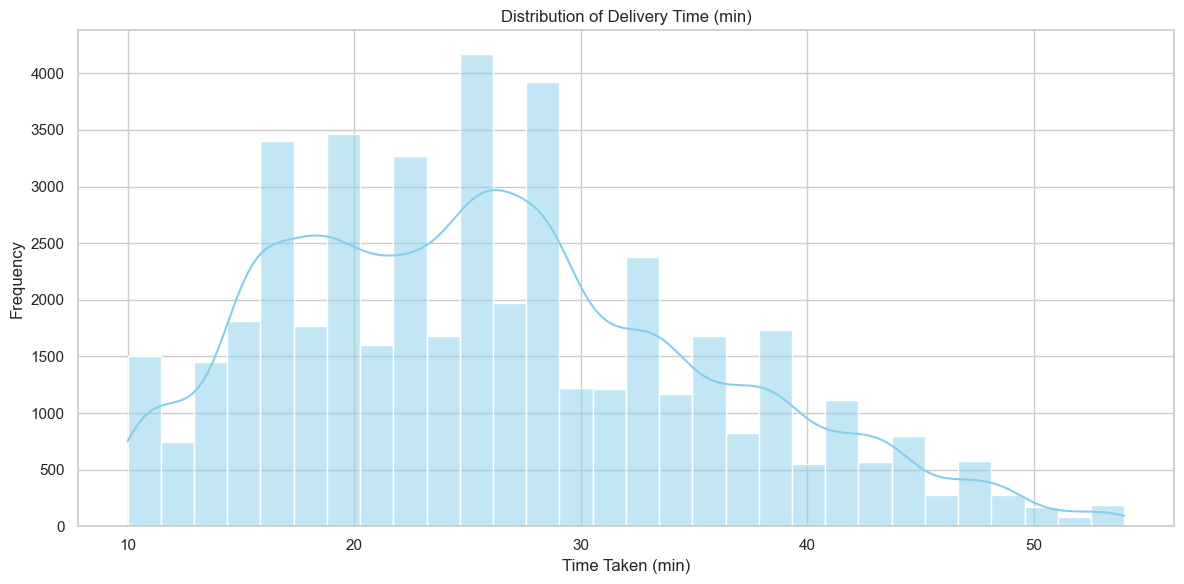

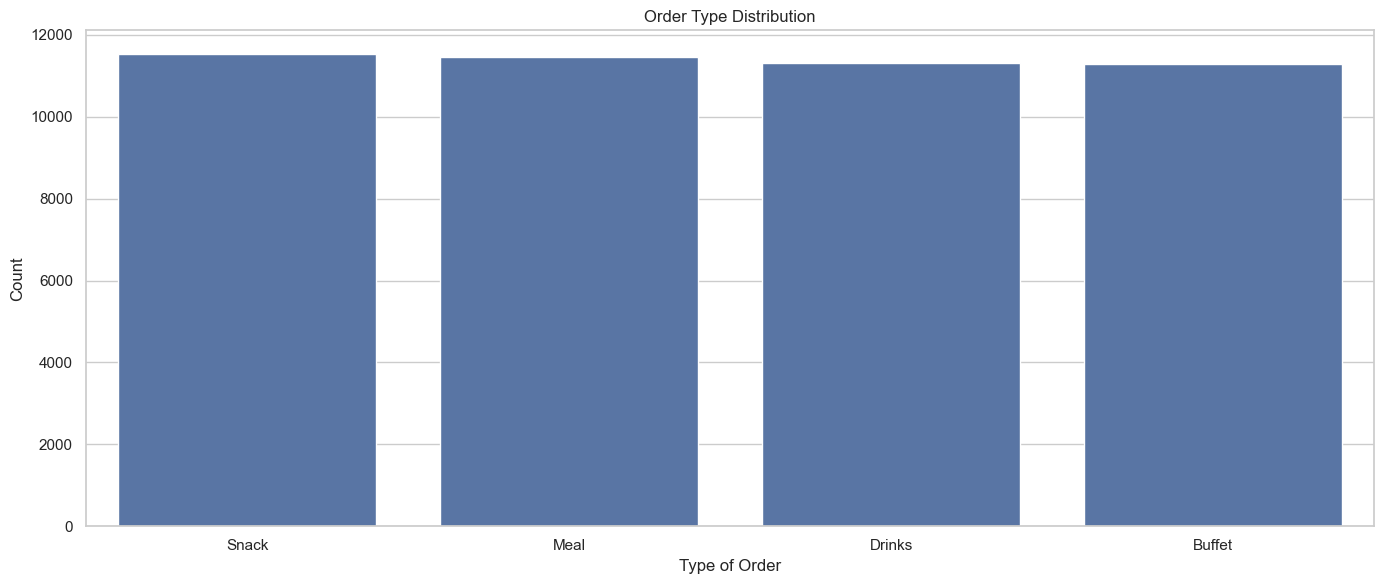

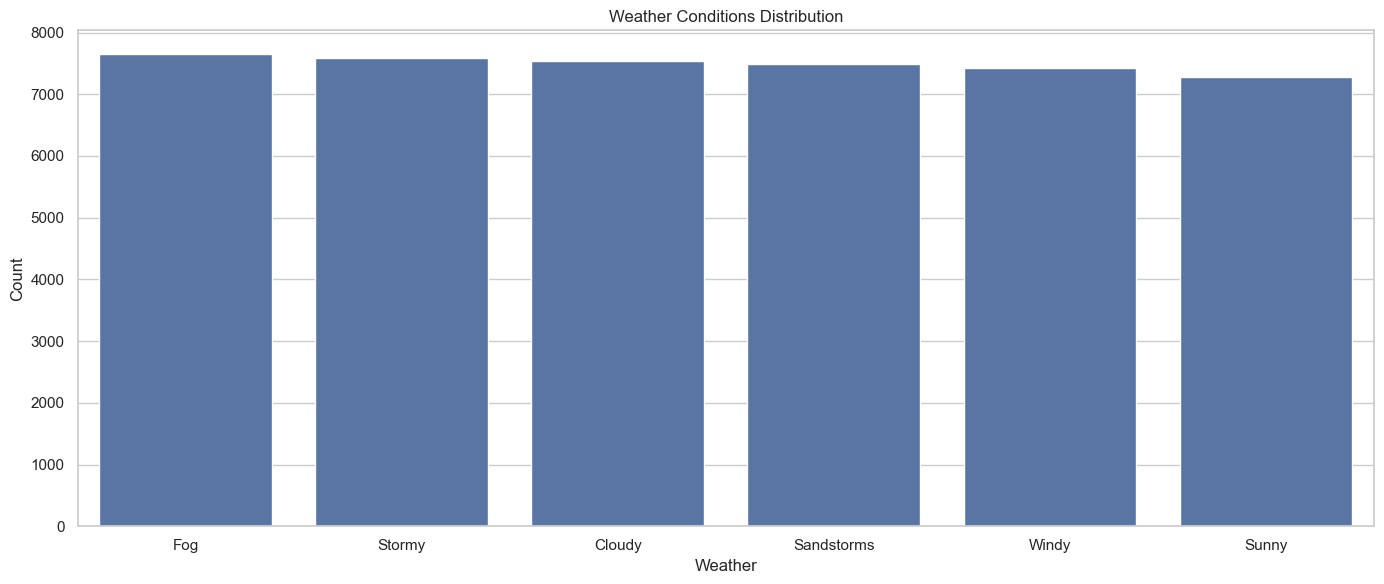

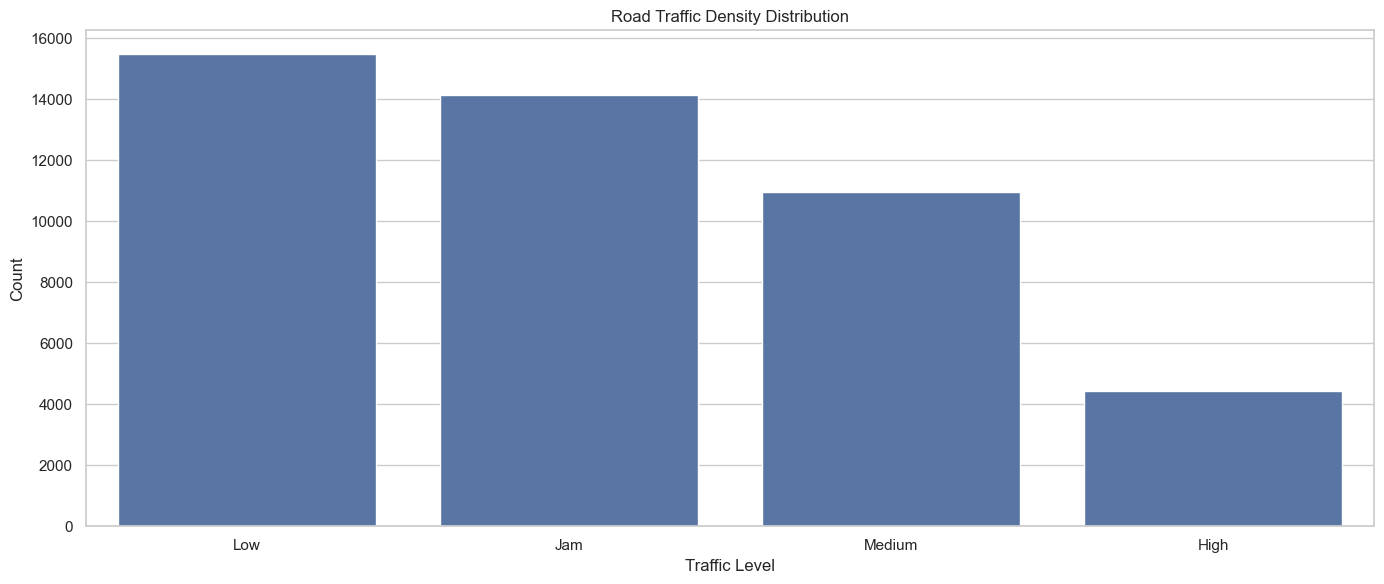

In [4]:
# -------------------- NUMERIC DISTRIBUTIONS --------------------
plt.figure(figsize=(12, 6))
sns.histplot(df['Time_taken (min)'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Delivery Time (min)")
plt.xlabel("Time Taken (min)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -------------------- CATEGORICAL DISTRIBUTIONS --------------------
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Type_of_order', order=df['Type_of_order'].value_counts().index)
plt.title("Order Type Distribution")
plt.xlabel("Type of Order")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Weather_conditions', order=df['Weather_conditions'].value_counts().index)
plt.title("Weather Conditions Distribution")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Road_traffic_density', order=df['Road_traffic_density'].value_counts().index)
plt.title("Road Traffic Density Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



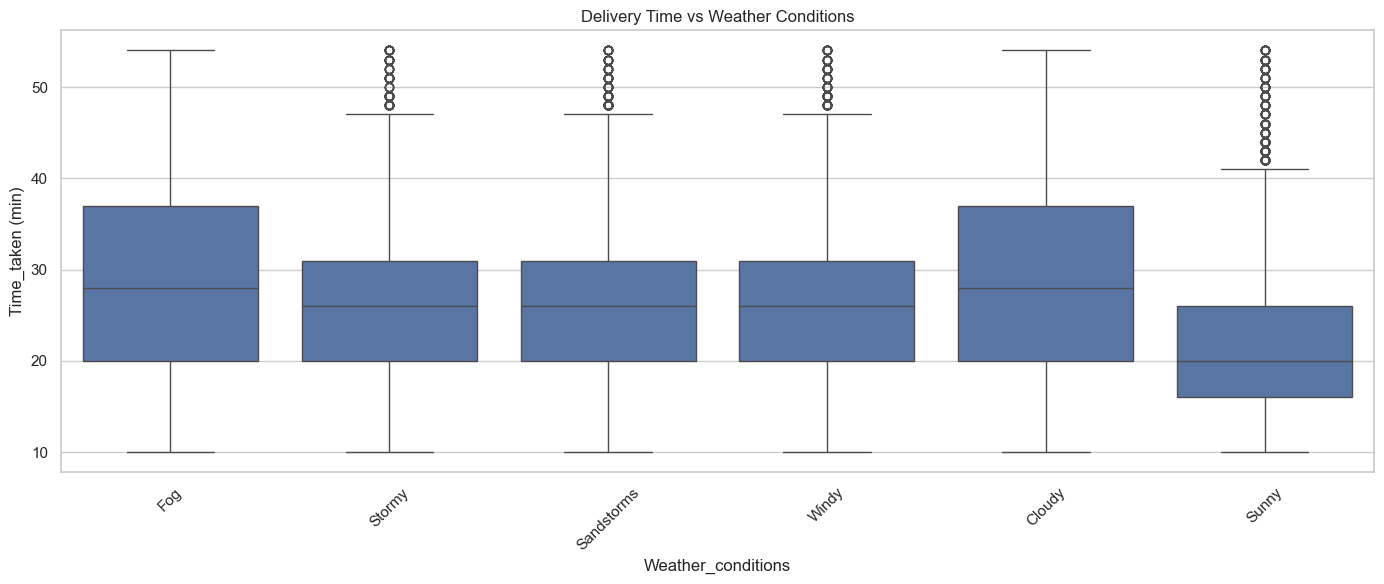

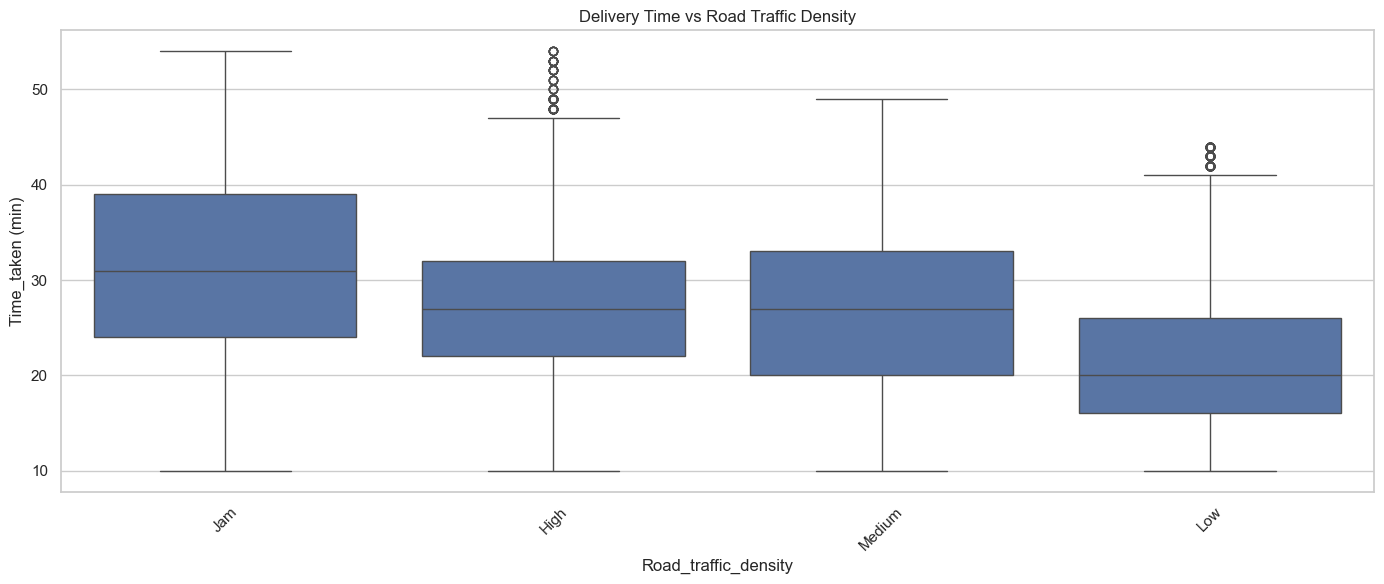

In [6]:
# -------------------- BOX PLOTS --------------------
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Weather_conditions', y='Time_taken (min)')
plt.title("Delivery Time vs Weather Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Road_traffic_density', y='Time_taken (min)')
plt.title("Delivery Time vs Road Traffic Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


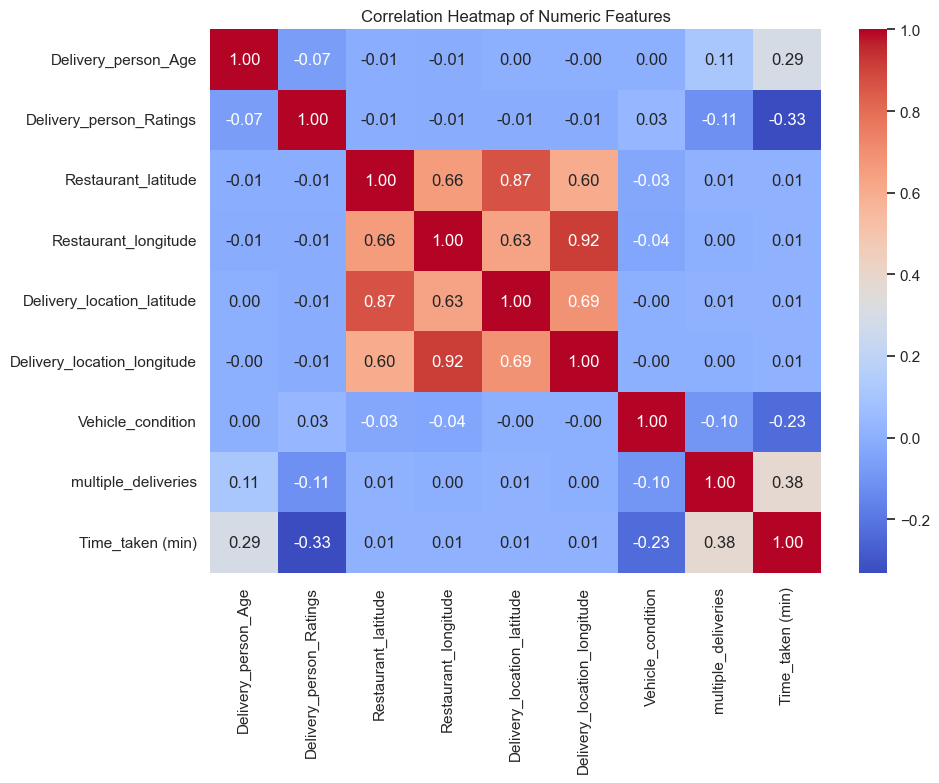

In [8]:

# -------------------- CORRELATION HEATMAP --------------------
numeric_df = df.select_dtypes(include=['int64', 'float64']).dropna()
correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


## Random Forest Evaluation Matrics

In [11]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv")  # Replace with actual file path if different

# Drop irrelevant and missing columns
df = df.dropna()  # Ensure clean dataset

# Define dependent and independent variables
target = 'Time_taken (min)'
X = df.drop(columns=[target, 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
y = df[target]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Initialize and train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Random Forest Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")


🔍 Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 23.17
R² Score: 0.7370


## Random forest Model Training

🔍 Random Forest Model Evaluation:
✅ Accuracy :  0.7595
✅ Precision:  0.7597
✅ Recall   :  0.7595
✅ F1 Score :  0.7564


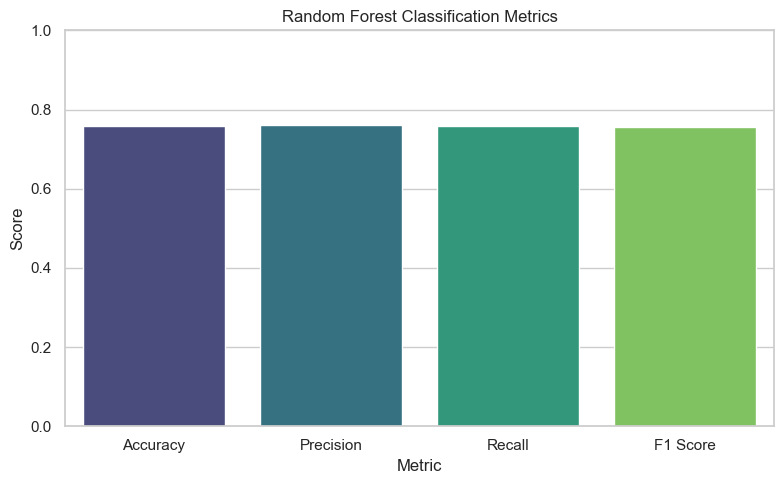

In [13]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the cleaned dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv")  # Update path if needed

# Drop rows with missing values
df = df.dropna()

# Convert delivery time into categories
def categorize_time(t):
    if t < 20:
        return 'fast'
    elif t <= 35:
        return 'medium'
    else:
        return 'slow'

df['Time_Category'] = df['Time_taken (min)'].apply(categorize_time)

# Define features and target
X = df.drop(columns=['Time_taken (min)', 'Time_Category', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
y = df['Time_Category']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split into train and test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred = rf_clf.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print metrics
print("🔍 Random Forest Model Evaluation:")
print(f"✅ Accuracy :  {accuracy:.4f}")
print(f"✅ Precision:  {precision:.4f}")
print(f"✅ Recall   :  {recall:.4f}")
print(f"✅ F1 Score :  {f1:.4f}")

# Create DataFrame for metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

# Plotting the bar graph
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', palette='viridis', legend=False)
plt.title("Random Forest Classification Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()


## Tunned Random Forest

Fitting 3 folds for each of 48 candidates, totalling 144 fits
🎯 Best Parameters Found: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

🔍 Tuned Random Forest Evaluation:
✅ Accuracy :  0.7635
✅ Precision:  0.7636
✅ Recall   :  0.7635
✅ F1 Score :  0.7607


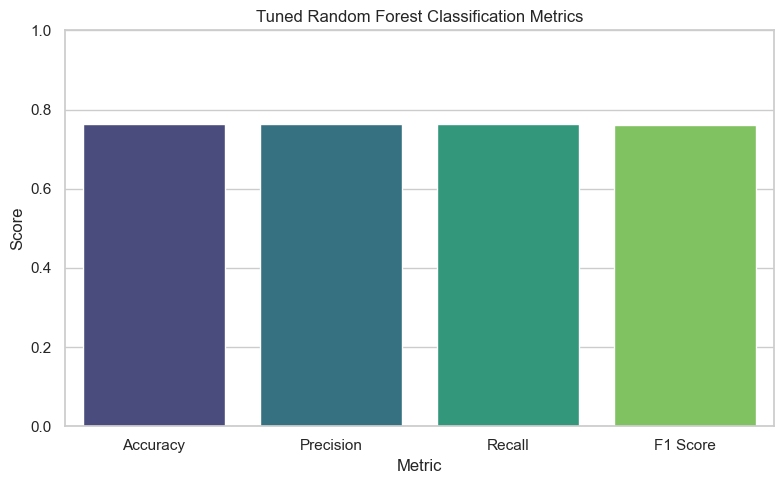

In [17]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the cleaned dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv")  # Replace with correct path

# Drop missing rows
df = df.dropna()

# Convert time into categories
def categorize_time(t):
    if t < 20:
        return 'fast'
    elif t <= 35:
        return 'medium'
    else:
        return 'slow'

df['Time_Category'] = df['Time_taken (min)'].apply(categorize_time)

# Define X and y
X = df.drop(columns=['Time_taken (min)', 'Time_Category', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
X = pd.get_dummies(X, drop_first=True)
y = df['Time_Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Grid search with 3-fold cross-validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, 
                           cv=3, n_jobs=-1, scoring='f1_weighted', verbose=1)
grid_search.fit(X_train, y_train)

# Get the best estimator
best_rf = grid_search.best_estimator_

# Predict on test set
y_pred = best_rf.predict(X_test)

# Evaluate tuned model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print best parameters and metrics
print("🎯 Best Parameters Found:", grid_search.best_params_)
print("\n🔍 Tuned Random Forest Evaluation:")
print(f"✅ Accuracy :  {accuracy:.4f}")
print(f"✅ Precision:  {precision:.4f}")
print(f"✅ Recall   :  {recall:.4f}")
print(f"✅ F1 Score :  {f1:.4f}")

# Create metrics DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

# Plot the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', palette='viridis', legend=False)
plt.title("Tuned Random Forest Classification Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()


Fitting 3 folds for each of 2 candidates, totalling 6 fits
🎯 Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📊 Tuned Random Forest Evaluation Metrics:
✅ Accuracy :  0.7595
✅ Precision:  0.7597
✅ Recall   :  0.7595
✅ F1 Score :  0.7564


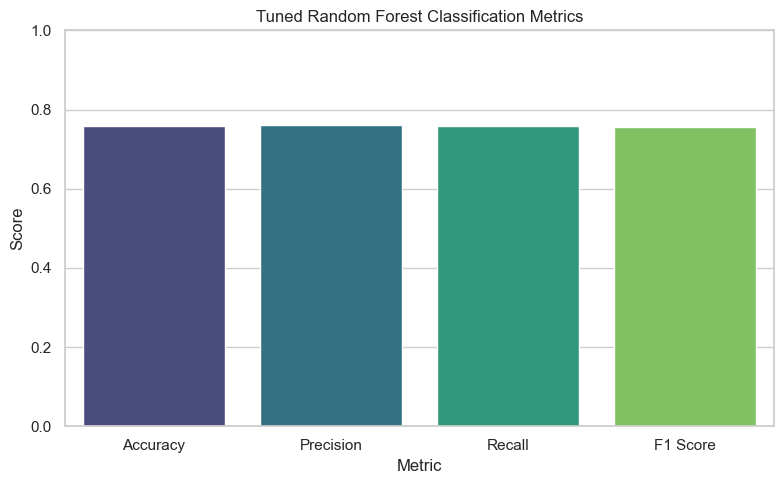

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load cleaned dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv")
df = df.dropna()

# Categorize delivery time
def categorize_time(t):
    if t < 20:
        return 'fast'
    elif t <= 35:
        return 'medium'
    else:
        return 'slow'

df['Time_Category'] = df['Time_taken (min)'].apply(categorize_time)

# Prepare features and target
X = df.drop(columns=['Time_taken (min)', 'Time_Category', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
X = pd.get_dummies(X, drop_first=True)
y = df['Time_Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lightweight grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100],
    'max_depth': [None, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# Grid search with 3-fold CV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# Predict and evaluate
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print results
print("🎯 Best Parameters:", grid_search.best_params_)
print("\n📊 Tuned Random Forest Evaluation Metrics:")
print(f"✅ Accuracy :  {accuracy:.4f}")
print(f"✅ Precision:  {precision:.4f}")
print(f"✅ Recall   :  {recall:.4f}")
print(f"✅ F1 Score :  {f1:.4f}")

# Plot metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', palette='viridis', legend=False)
plt.title("Tuned Random Forest Classification Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()


## Linear Regression

📊 Linear Regression (used for Classification) Evaluation Metrics:
✅ Accuracy :  0.6853
✅ Precision:  0.6978
✅ Recall   :  0.6853
✅ F1 Score :  0.6708


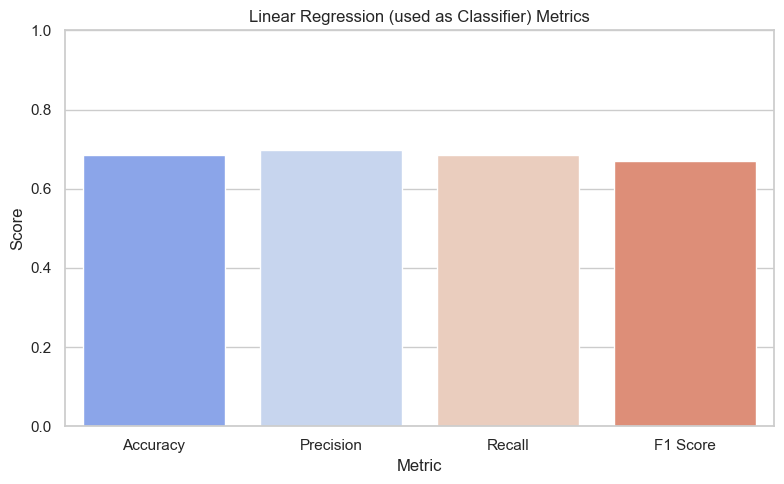

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Load cleaned dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv")
df = df.dropna()

# Step 1: Categorize time
def categorize_time(t):
    if t < 20:
        return 0  # fast
    elif t <= 35:
        return 1  # medium
    else:
        return 2  # slow

df['Time_Class'] = df['Time_taken (min)'].apply(categorize_time)

# Step 2: Define X and y
X = df.drop(columns=['Time_taken (min)', 'Time_Class', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
X = pd.get_dummies(X, drop_first=True)
y = df['Time_Class']

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Fit Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Step 5: Predict and round to nearest class (0, 1, 2)
y_pred_cont = lin_reg.predict(X_test)
y_pred = np.clip(np.round(y_pred_cont), 0, 2).astype(int)  # Clip to valid class range

# Step 6: Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Step 7: Print and Plot
print("📊 Linear Regression (used for Classification) Evaluation Metrics:")
print(f"✅ Accuracy :  {accuracy:.4f}")
print(f"✅ Precision:  {precision:.4f}")
print(f"✅ Recall   :  {recall:.4f}")
print(f"✅ F1 Score :  {f1:.4f}")

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', palette='coolwarm', legend=False)
plt.title("Linear Regression (used as Classifier) Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()


## Support Vector Regression Model

📊 Support Vector Regression (used as Classifier) Evaluation Metrics:
✅ Accuracy :  0.6733
✅ Precision:  0.6850
✅ Recall   :  0.6733
✅ F1 Score :  0.6572


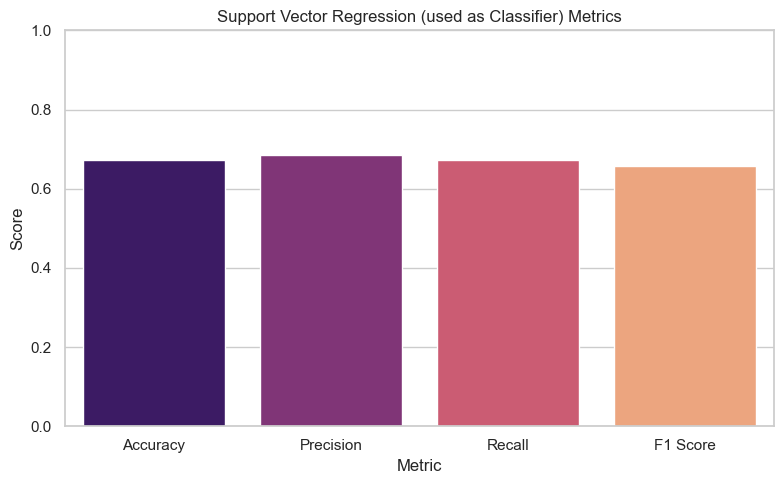

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Load and clean dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv")
df = df.dropna()

# Convert time to class
def categorize_time(t):
    if t < 20:
        return 0  # fast
    elif t <= 35:
        return 1  # medium
    else:
        return 2  # slow

df['Time_Class'] = df['Time_taken (min)'].apply(categorize_time)

# Use only a smaller sample to speed up SVR
df_sample = df.sample(n=3000, random_state=42)

# Prepare X and y
X = df_sample.drop(columns=['Time_taken (min)', 'Time_Class', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
X = pd.get_dummies(X, drop_first=True)
y = df_sample['Time_Class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVR
svr = SVR(kernel='linear')
svr.fit(X_train, y_train)

# Predict and round to class labels
y_pred_cont = svr.predict(X_test)
y_pred = np.clip(np.round(y_pred_cont), 0, 2).astype(int)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print metrics
print("📊 Support Vector Regression (used as Classifier) Evaluation Metrics:")
print(f"✅ Accuracy :  {accuracy:.4f}")
print(f"✅ Precision:  {precision:.4f}")
print(f"✅ Recall   :  {recall:.4f}")
print(f"✅ F1 Score :  {f1:.4f}")

# Plot metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', palette='magma', legend=False)
plt.title("Support Vector Regression (used as Classifier) Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load and clean dataset
df = pd.read_csv("Cleaned_Zomato_Dataset.csv").dropna()

# Categorize delivery time
def categorize_time(t):
    if t < 20:
        return 0
    elif t <= 35:
        return 1
    else:
        return 2

df['Time_Class'] = df['Time_taken (min)'].apply(categorize_time)

# Smaller sample for SVR to reduce runtime
df_svr_sample = df.sample(n=3000, random_state=42)

# Prepare function for dataset splitting
def prepare_data(dataframe):
    X = dataframe.drop(columns=['Time_taken (min)', 'Time_Class', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
    y = dataframe['Time_Class']
    X = pd.get_dummies(X, drop_first=True)
    return train_test_split(X, y, test_size=0.2, random_state=42)

# Universal evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, is_regression=False):
    if is_regression:
        model.fit(X_train, y_train)
        y_pred_cont = model.predict(X_test)
        y_pred = np.clip(np.round(y_pred_cont), 0, 2).astype(int)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

# Split the main dataset
X_train, X_test, y_train, y_test = prepare_data(df)

# Create results dictionary
model_results = {}

# 1. Random Forest (Tuned)
param_grid = {
    'n_estimators': [100],
    'max_depth': [None, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, scoring='f1_weighted', cv=3, n_jobs=-1)
model_results["Random Forest (Tuned)"] = evaluate_model(grid_rf, X_train, X_test, y_train, y_test)

# 2. Linear Regression (used as classifier)
lin_reg = LinearRegression()
model_results["Linear Regression (as Classifier)"] = evaluate_model(lin_reg, X_train, X_test, y_train, y_test, is_regression=True)

# 3. SVR (used as classifier) on sampled data
X_train_svr, X_test_svr, y_train_svr, y_test_svr = prepare_data(df_svr_sample)
svr_model = SVR(kernel='linear')
model_results["SVR (as Classifier)"] = evaluate_model(svr_model, X_train_svr, X_test_svr, y_train_svr, y_test_svr, is_regression=True)

# 4. Logistic Regression with StandardScaler and max_iter fix
log_reg_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model_results["Logistic Regression (scaled)"] = evaluate_model(log_reg_pipeline, X_train, X_test, y_train, y_test)

# Convert results to DataFrame
comparison_df = pd.DataFrame(model_results).T.round(4)
comparison_df.reset_index(inplace=True)
comparison_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

# Display the comparison table
print("\n📊 Final Model Comparison Table:\n")
print(comparison_df)



📊 Final Model Comparison Table:

                               Model  Accuracy  Precision  Recall  F1 Score
0              Random Forest (Tuned)    0.7595     0.7597  0.7595    0.7564
1  Linear Regression (as Classifier)    0.6853     0.6978  0.6853    0.6708
2                SVR (as Classifier)    0.6733     0.6850  0.6733    0.6572
3       Logistic Regression (scaled)    0.6800     0.6815  0.6800    0.6722
